# Part 1 — DEM: San Francisco Elevation Contours → H3

**A complete DEM download → elevation isobands → product-native H3 polyfill → per-band rasterize → multi-band stack pipeline,
demonstrated on USGS 3DEP 10 m elevation data for San Francisco.**

## What this notebook shows

San Francisco is ideal terrain for elevation isobands: sea level at the Bay and Pacific coast rises
sharply through the Mission and Castro neighborhoods up to Twin Peaks (~280 m) and Mt Davidson
(~282 m). The ~300 m spread over the city AOI produces twelve meaningful 25 m elevation bands.

1. **Download a DEM** — `DemDownloader().download(SF_BBOX, DEM_DIR, resolution="finest")` fetches the
   USGS **3DEP seamless 10 m** dataset windowed to the San Francisco AOI via the Planetary Computer STAC
   API, staged to a UC Volume (idempotent).
2. **Read as a Spark DataFrame** — `.read(DEM_DIR)` returns a `tile` DataFrame (EPSG:4326, one row per tile).
3. **Extract elevation isobands** — `rx.rst_isoband("tile", breaks)` with 25 m breaks (0, 25, …, 300)
   produces **12 contiguous band polygons** as a distributed Spark column of WKB geometry.
4. **H3 polyfill via Databricks product H3** — `try_h3_polyfillash3` (centroid-in) or `try_h3_coverash3`
   (overlap), selected by `POLYFILL_MODE`, fills each band polygon at **H3 resolution 10** (~65 m edge).
   Fully distributed — no driver-side h3-py.
5. **Shared grid spec** — `rx.rst_h3_gridspec` snaps a single pixel-aligned canvas over all bands combined.
6. **Per-band rasterize** — `rx.rst_h3_rasterize_agg` burns each band's H3 cells onto the shared canvas.
7. **Stack** — `rx.rst_frombands_agg` assembles per-band tiles into a single multi-band GeoTIFF;
   `plot_raster(composite="depth")` renders coverage depth.

## Part 1 of 3

| Notebook | Input | Key GeoBrix function |
|---|---|---|
| **Part 1 — DEM** (this notebook) | USGS 3DEP 10 m raster | `rst_isoband` → product H3 |
| **Part 2 — LiDAR→DSM** | LiDAR point cloud | `rst_binpoints` |
| **Part 3 — CHM** | DSM − DTM | `rst_chm` |

> **Resolution note:** H3 res 10 (~65 m edge) suits terrain-scale visualisation. Telco and precision
> use cases at res 13–15 (~10 m–1 m) require the finer elevation detail produced in Parts 2 and 3.

## Runtime requirement

Run on Databricks Serverless compute (or any cluster with UC Volumes access). The 3DEP tile is staged
by the cell below — once, idempotent. Outputs are empty until executed on a cluster.

---
_Last Modified: September 17, 2026_

![H3 Rasterize — DEM isobands to a multi-band H3 raster stack](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/h3-rasterize/h3-rasterize.png)

## Install GeoBrix

The lightweight `[light_env6,vizx]` extras are sufficient — no JAR or GDAL init script
required (when using the lightweight tier). The notebook can run on Serverless compute.

In [ ]:
# Install GeoBrix with lightweight raster + visualization extras.
# Replace the file:// path with your staged wheel location.
# Two-step interactive form: --no-deps --force-reinstall swaps fresh bytes without
# touching preinstalled pyspark/idna/etc., then a plain install pulls the extras.
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix[light_env6,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet "geobrix[light_env6,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"

In [0]:
%restart_python

## Imports and registration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import functions as F

# GeoBrix lightweight tier — runs on Serverless.
from databricks.labs.gbx.pyrx import functions as rx
from databricks.labs.gbx.ds.register import register
from databricks.labs.gbx.vizx import plot_raster, plot_static, plot_mask_layers, cells_as_gdf, grid_as_gdf

# Register pyrx SQL UDFs and H3 UDTFs (rst_h3_rastertogridavg, etc.).
rx.register(spark)
register(spark)

In [ ]:
INTERACTIVE_PLOTS = False  # set True for interactive MapLibre maps

## DEM path and parameters

`DemDownloader` wraps the **USGS 3DEP seamless** dataset hosted on Microsoft Planetary Computer.
With `resolution="finest"` it queries the 10 m product for tiles intersecting `SF_BBOX`, downloads
them, and writes GeoTIFF files to `DEM_DIR` in the UC Volume — idempotent on repeat runs.

> **Swap to 2 m LiDAR in one line:** `DemDownloader.lidar_dtm().download(SF_BBOX, DEM_DIR)` fetches the
> 3DEP-LiDAR-DTM product (~2 m resolution) to the same Volume layout, no other pipeline change needed.
> That 2 m DEM is the input for Part 2.

In [ ]:
# --- area & output ---
SF_BBOX = (-122.52, 37.70, -122.35, 37.83)          # San Francisco city (lon/lat)
DEM_DIR = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation-3dep"

# --- parameters ---
H3_RESOLUTION = 10                                   # ~65 m edge (Telco wants 13-15; see Notebooks 2/3)
BAND_STEP_M   = 25
BREAKS        = [float(b) for b in range(0, 301, BAND_STEP_M)]   # 0,25,...,300 -> 12 bands
POLYFILL_MODE = "polyfill"                           # "polyfill" (centroid-in) | "coveras" (overlap)

# shared H3 canvas pixel size: ~3 px per res-10 hex edge (~65.9 m) at SF latitude
import math
_EDGE_M = 65.9
PIXEL_SIZE_DEG = (_EDGE_M / 3.0) / (111320.0 * math.cos(math.radians(37.8)))
print(f"H3 res {H3_RESOLUTION} | breaks {BREAKS} | pixel {PIXEL_SIZE_DEG:.7f} deg")

### Stage the 3DEP DEM

`DemDownloader().download(SF_BBOX, DEM_DIR, resolution="finest")` queries the Planetary Computer
STAC for USGS 3DEP seamless tiles intersecting `SF_BBOX`, downloads them, and writes the result to
the Volume — **once, idempotent** (skips files that already exist). Safe on Serverless: uses
rasterio's bundled GDAL, no CLI tools required.

In [ ]:
from databricks.labs.gbx.sample.dem import DemDownloader
dem = DemDownloader()                                # 3dep-seamless (10/30 m)
meta = dem.download(SF_BBOX, DEM_DIR, resolution="finest")   # 10 m via Planetary Computer STAC
meta.select("item_id", "out_file_path", "out_file_sz", "is_out_file_valid").show(truncate=False)

## Step 1 — Load DEM and extract elevation isobands

`DemDownloader().read(DEM_DIR)` returns a **Spark DataFrame** of `tile` structs (EPSG:4326, one row
per downloaded tile). `rx.rst_isoband("tile", breaks)` runs as a **distributed Spark column
expression** — each executor processes one tile and emits rows of
`(band_level, geom_wkb, elev_lo, elev_hi)` for every contiguous elevation band.

With 25 m breaks from 0 to 300 m, the SF DEM yields **12 elevation bands**: from sea-level coastal
areas through the city's mid-slope neighborhoods up to the hilltops near Twin Peaks. Each row's
`geom_wkb` column holds the polygon as **WKB BINARY** — the native input format for Databricks
product H3 functions in the next step.

In [ ]:
tiles = DemDownloader().read(DEM_DIR)                # 'tile' struct, EPSG:4326 (1..N 3DEP tiles)
breaks_arr = F.array(*[F.lit(b) for b in BREAKS])
patches = (tiles
    .select(F.explode(rx.rst_isoband("tile", breaks_arr)).alias("p"))
    .select(F.col("p.band").alias("band_level"),
            F.col("p.geom_wkb").alias("geom_wkb"),
            F.col("p.lower").alias("elev_lo"),
            F.col("p.upper").alias("elev_hi")))
patches.groupBy("band_level", "elev_lo", "elev_hi").count().orderBy("band_level").show()

### Render the DEM

The source elevation tile via `plot_raster` (auto-decimation + per-band 2–98% percentile stretch; single-band → viridis).

In [ ]:
# Render the source DEM from the first downloaded tile.
# tiles.first() triggers a Spark action (reads from the Volume); raster bytes
# come back as BINARY in the tile struct. Single-band → viridis gradient is a
# reasonable default; if a terrain colormap is needed, plot_file on a staged
# .tif with cmap="terrain" is an alternative (see findings).
plot_raster(tiles.first()["tile"]["raster"], fig_w=8, fig_h=6)

## Step 2 — H3 polyfill: isobands → H3 cells

`rst_isoband` emits `geom_wkb` as **WKB BINARY** — the exact format Databricks product H3 functions
accept. The hand-off from GeoBrix geometry to Databricks H3 indexing is a direct SQL expression:

    LATERAL VIEW explode(try_h3_polyfillash3(geom_wkb, 10)) t AS cellid

**Two polyfill modes** (controlled by `POLYFILL_MODE`):

| Mode | Function | Cell included when… |
|---|---|---|
| `"polyfill"` | `try_h3_polyfillash3` | Cell **centroid** falls inside the polygon |
| `"coveras"` | `try_h3_coverash3` | Cell **overlaps** the polygon (any intersection) |

`coverash3 ⊇ polyfillash3`: the overlap mode returns at least as many cells and better preserves
narrow features at band boundaries.

> **WKB, not GEOMETRY.** The product H3 functions accept WKB BINARY and **reject the GEOMETRY type** —
> do not wrap `geom_wkb` in `ST_GeomFromWKB`. The `try_*` prefix returns NULL for degenerate patches
> instead of failing the job.

Both `rst_isoband` (Step 1) and the H3 polyfill run as **distributed Spark expressions** — no
driver-side `h3.polygon_to_cells`, no `collect()`. This is the **GeoBrix → Databricks-native H3
on-ramp**: GeoBrix extracts the geometry; the Databricks platform handles spatial indexing at scale.

In [ ]:
# Hand off to Databricks-native H3. rst_isoband emits WKB; product H3 accepts WKB BINARY
# directly (it REJECTS the GEOMETRY type -> do NOT wrap in ST_GeomFromWKB). try_* returns
# NULL on a bad/degenerate patch instead of failing the job. Fully distributed - no driver polyfill.
patches.createOrReplaceTempView("_patches")
_h3fn = "try_h3_polyfillash3" if POLYFILL_MODE == "polyfill" else "try_h3_coverash3"
cells_df = spark.sql(f"""
    SELECT band_level, cellid
    FROM _patches
    LATERAL VIEW explode({_h3fn}(geom_wkb, {H3_RESOLUTION})) t AS cellid
    WHERE cellid IS NOT NULL
""").distinct()
cells_df.groupBy("band_level").count().orderBy("band_level").show()

### Render the H3 polyfill

`plot_static` draws the polyfilled cells straight from the Spark DataFrame: with
`grid_system="h3"` it turns each `cellid` into its hexagon boundary and colours it by
elevation band, over a basemap (also can plot geoms). Each cell keeps its own geometry, so this per-cell view
is handy for inspecting individual hexagons at this data size. It renders as a static
image (so it shows on GitHub and the docs site); for an interactive pan/zoom map, pass the
same Spark DataFrame to `vizx.plot_interactive(cells_df, grid_system="h3", column="band_level")`
— it handles scale (falling back to a raster overlay for very large cell sets) and renders
inline in Databricks.

__Note:__ for much larger cell sets, dissolve first —
`cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"], dissolve_by="band_level")`
merges each band into a single footprint polygon (far fewer geometries to render), then
pass that GeoDataFrame to `plot_static`. (`plot_static` itself renders one hexagon per
cell; dissolving lives on the `cells_as_gdf` adapter.)

In [ ]:
# Dissolve per-cell hexagons into one footprint polygon per band before rendering.
# cells_as_gdf with dissolve_by="band_level" merges each band into one polygon, so
# plot_static receives at most 12 rows instead of potentially >10k hex boundaries —
# no truncation risk and a much cleaner render.
cells_gdf = cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"], dissolve_by="band_level")
ax = plot_static(
    cells_gdf,
    column="band_level",
    cmap="viridis",
    title="H3 polyfill — cells by elevation band",
)

## Step 3 — Shared grid spec via `rst_h3_gridspec`

`rx.rst_h3_gridspec` computes a pixel-snapped bounding box and pixel dimensions
that span **all** H3 cells across **all** band levels. Because we pass no
grouping column here (we want a single shared canvas), it returns a single-row
DataFrame with a `grid` struct.

Using the same `grid` for every band ensures all per-band tiles are spatially
aligned — a prerequisite for `rst_frombands_agg` to produce a coherent stack.

In [0]:
# Compute the shared canvas over ALL cells (no grouping column → one grid row).
grid_df = rx.rst_h3_gridspec(cells_df, "cellid", pixel_size=PIXEL_SIZE_DEG)
grid_row = grid_df.first()
g = grid_row["grid"]

print("Shared canvas grid spec:")
print(f"  xmin={g['xmin']:.6f}  ymin={g['ymin']:.6f}")
print(f"  xmax={g['xmax']:.6f}  ymax={g['ymax']:.6f}")
print(f"  pixel_size={g['pixel_size']:.6f}")
print(f"  width={g['width']}  height={g['height']}  srid={g['srid']}")

# Broadcast the grid constants to all rows so rst_h3_rasterize_agg
# receives the same extent per group.
cells_with_grid = cells_df.withColumn("xmin",   F.lit(g["xmin"]))\
                           .withColumn("ymin",   F.lit(g["ymin"]))\
                           .withColumn("xmax",   F.lit(g["xmax"]))\
                           .withColumn("ymax",   F.lit(g["ymax"]))\
                           .withColumn("width",  F.lit(g["width"]))\
                           .withColumn("height", F.lit(g["height"]))

Shared canvas grid spec:
  xmin=-122.993628  ymin=36.992336
  xmax=-121.988719  ymax=38.009329
  pixel_size=0.002014
  width=499  height=505  srid=4326


### Render the shared canvas over the cells
  
`rst_h3_gridspec` returns the shared raster canvas — the bounding rectangle (and
pixel grid) every per-band raster aligns to. Drawing that rectangle over the cells
shows the extent the H3 cells get binned into: we render the cells with
`plot_static`, then overlay the canvas outline on the same axes.

`plot_static` reprojects layers to Web Mercator (EPSG:3857) so they line up with
the basemap, so the boundary overlay is reprojected to match before drawing.

In [ ]:
# Multi-layer (static): per-band H3 footprints + the shared-canvas rectangle on
# one matplotlib axes, over a basemap. Static so it renders on GitHub + the docs (see
# the note above); for an interactive pan/zoom map, build GeoDataFrames with
# cells_as_gdf(...) / grid_as_gdf(...) and pass to plot_interactive([vector_layer(...)]).
grid_gdf = grid_as_gdf(g)  # g = grid_row["grid"] -> the shared canvas spec

# Dissolve into one footprint polygon per band (avoids >10k-row truncation in plot_static).
cells_gdf = cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"], dissolve_by="band_level")

# Cells coloured by elevation band over a basemap, then the shared canvas as a red
# OUTLINE (fill=False so it doesn't cover the cells; basemap=False so it doesn't
# re-fetch tiles). Both layers reproject to 3857 and align.
ax = plot_static(
    cells_gdf,
    column="band_level",
    cmap="viridis",
    title="H3 cells by elevation band + shared canvas",
)
ax = plot_static(grid_gdf, ax=ax, fill=False, edgecolor="red", basemap=False)

## Step 4 — Per-band rasterize with `rst_h3_rasterize_agg`

`rst_h3_rasterize_agg` burns a group's H3 cells onto the shared canvas,
producing a presence mask (1.0 where a cell's centroid falls, NoData elsewhere).
Supplying the explicit extent from `rst_h3_gridspec` guarantees every per-band
tile has identical pixel dimensions — which is required for stacking.

We group by `band_level` so each of the **12 elevation thresholds** produces one
pixel-aligned tile.

Because the per-pixel rasterize is expensive and we read these tiles again in the
next two steps, we materialize them once into a **session-scoped [temporary table](https://docs.databricks.com/aws/en/tables/temporary-tables)**
(`CREATE TEMP TABLE`). On Serverless, `.cache()` / `.persist()` are unavailable, so a
temp table is the idiomatic way to avoid recomputing the burn; it is automatically
dropped when the session ends. Requires Serverless or DBR 18.1+ (not dedicated /
single-user clusters).

In [0]:
# One rasterized tile per band level, all on the shared canvas.
bands_df = cells_with_grid.groupBy("band_level").agg(
    rx.rst_h3_rasterize_agg(
        "cellid",
        xmin="xmin",
        ymin="ymin",
        xmax="xmax",
        ymax="ymax",
        width="width",
        height="height",
    ).alias("tile")
)

# Materialize the per-band tiles ONCE into a session-scoped TEMP TABLE. The
# per-pixel rasterize is expensive, and on Serverless .cache()/.persist() are
# unavailable -- a temporary table is the idiomatic way to materialize an
# intermediate so the next two steps read it back instead of recomputing the burn.
# It is auto-dropped when the session ends. Requires Serverless or DBR 18.1+
# (NOT supported on dedicated / single-user clusters). Temp tables are created via
# SQL DDL over a temp view -- the DataFrame writer API does not apply to them.
bands_df.createOrReplaceTempView("_bands_src")
spark.sql("CREATE OR REPLACE TEMP TABLE band_tiles AS SELECT * FROM _bands_src")
bands_df = spark.table("band_tiles").orderBy("band_level")

print(f"Band tiles: {bands_df.count()} rows")
bands_df.select("band_level",
                F.expr("gbx_rst_width(tile)  AS px_width"),
                F.expr("gbx_rst_height(tile) AS px_height"),
                F.expr("gbx_rst_numbands(tile) AS numbands")).show()

Band tiles: 8 rows
+----------+--------+---------+--------+
|band_level|px_width|px_height|numbands|
+----------+--------+---------+--------+
|         0|     499|      505|       1|
|       100|     499|      505|       1|
|       200|     499|      505|       1|
|       300|     499|      505|       1|
|       400|     499|      505|       1|
|       500|     499|      505|       1|
|       600|     499|      505|       1|
|       700|     499|      505|       1|
+----------+--------+---------+--------+



### Inspect band coverage shapes

Each per-band tile is a binary presence mask (1.0 where a cell centroid falls,
NoData elsewhere). We overlay two **mid-coverage** bands on a single plot — each a
distinct colour with a legend — so you can see directly how coverage shrinks toward
the hilltops as the elevation threshold rises. The lower (larger) band is drawn
first and the higher (smaller) band on top; both read cheaply from the `band_tiles`
temp table, and NoData is transparent over a light-grey background.

In [ ]:
# Overlay two MID-coverage bands on one plot (each a distinct colour + legend) to
# show how coverage shrinks with elevation. The lowest band fills the canvas and the
# highest is a sparse speck, so pick bands between ~8% and ~45% of the densest. Both
# rows read from the band_tiles temp table -- no rasterization is recomputed here.

counts = {r["band_level"]: r["count"]
          for r in cells_df.groupBy("band_level").count().collect()}
mx = max(counts.values())
sweet = [lvl for lvl in sorted(counts) if 0.08 * mx <= counts[lvl] <= 0.45 * mx]
if len(sweet) >= 2:
    show_levels = [sweet[0], sweet[-1]]          # lower (larger) first, higher on top
else:
    ordered = sorted(counts)
    show_levels = ordered[len(ordered) // 3: len(ordered) // 3 + 2] or ordered[:2]

layers = []
for lvl in show_levels:
    row = bands_df.filter(F.col("band_level") == lvl).first()
    label = f"{int(BREAKS[lvl])}–{int(BREAKS[lvl + 1])} m"   # en-dash range, e.g. "75–100 m"
    print(f"band_level = {lvl}  ({label}, {counts[lvl]} cells)")
    layers.append((label, row["tile"]["raster"]))

plot_mask_layers(layers, fig_w=8, fig_h=6,
                 title="band coverage shapes (higher threshold = smaller footprint)")

## Step 5 — Stack bands with `rst_frombands_agg`

`rst_frombands_agg` assembles the per-band tiles into a single multi-band
GeoTIFF, ordered by `band_level` ascending. Band 1 in the stacked raster
corresponds to the lowest elevation threshold (densest coverage — coastal and
low-lying areas); the highest band corresponds to the narrowest footprint
(hilltops near Twin Peaks).

The result is a single multi-band tile ready for downstream analysis: coverage-depth
visualisation, PMTiles export, or per-pixel elevation profiling.

In [0]:
# Add a sequential band_index starting at 1 so rst_frombands_agg orders correctly.
from pyspark.sql.window import Window

w = Window.orderBy("band_level")
indexed = bands_df.withColumn(
    "band_index",
    F.row_number().over(w).cast("int"),
)

# Stack all per-band tiles into one multi-band tile.
stacked_df = indexed.agg(
    rx.rst_frombands_agg("tile", "band_index").alias("stacked")
)

stacked_row = stacked_df.first()
stacked_tile = stacked_row["stacked"]
print("Stacked tile schema:", stacked_tile.asDict().keys())

# Quick metadata check via SQL accessors.
meta = stacked_df.selectExpr(
    "gbx_rst_numbands(stacked) AS n_bands",
    "gbx_rst_width(stacked)    AS width",
    "gbx_rst_height(stacked)   AS height",
    "gbx_rst_srid(stacked)     AS srid",
).first()
print(f"Bands: {meta['n_bands']}  Width: {meta['width']}  Height: {meta['height']}  SRID: {meta['srid']}")

Stacked tile schema: dict_keys(['cellid', 'raster', 'metadata'])
Bands: 8  Width: 499  Height: 505  SRID: 4326


### Visualize the stacked multi-band raster

`plot_raster` with `composite="depth"` renders **coverage depth**: the per-pixel
count of bands that cover each pixel (0 = uncovered, N = all twelve thresholds cover
that location). The result is a viridis gradient — high-altitude terrain covered by
only the lowest bands appears at the low end; valley floors and coastline covered by
all twelve thresholds appear at the high end. Uncovered pixels (the ocean and areas
outside SF) are masked transparent.

The depth map is far more readable than an RGB composite of presence masks, which is
dominated by black (NoData) and gives no sense of the underlying terrain.

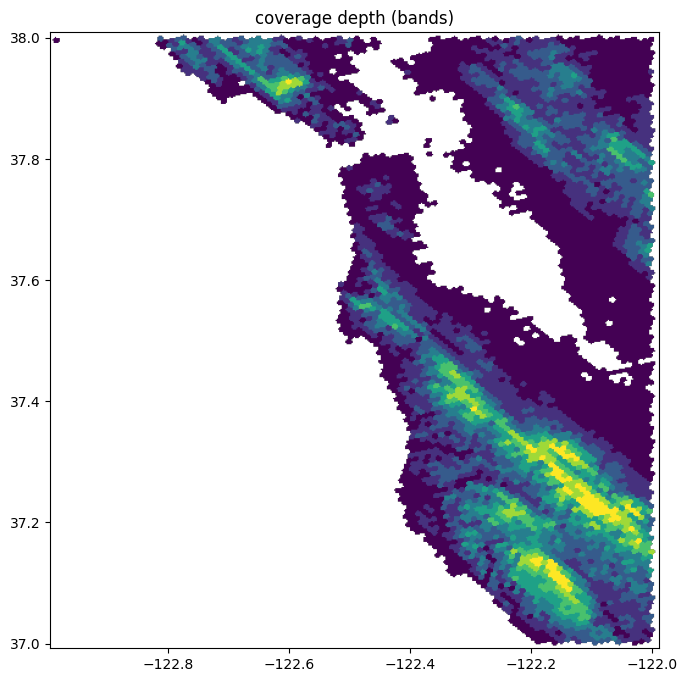

In [0]:
# Render the stacked raster as a coverage-depth map.
# composite="depth" counts, per pixel, how many bands cover it → viridis gradient.
# Uncovered pixels (NoData in all bands) are masked transparent.
plot_raster(stacked_tile["raster"], composite="depth", fig_w=10, fig_h=8)

Multi-layer view: the coverage-depth raster overlaid with H3 cell boundaries by elevation band — pan and zoom to explore the spatial distribution.

In [ ]:
if INTERACTIVE_PLOTS:
    from databricks.labs.gbx.vizx import raster_layer, grid_layer, plot_interactive
    plot_interactive([
        raster_layer(stacked_tile["raster"]),
        grid_layer(cells_df, grid_system="h3", cellid_col="cellid", column="band_level", opacity=0.25),
    ])

## Summary

This notebook demonstrated the full H3-cell rasterization pipeline on a San Francisco DEM,
producing **12 elevation bands** (0–300 m, 25 m step) at H3 resolution 10 using USGS 3DEP
seamless 10 m elevation data:

| Step | Function | Output |
|---|---|---|
| Download DEM (staged once) | `DemDownloader().download(…)` | GeoTIFF tiles in UC Volume |
| DEM → isobands (Spark) | `rx.rst_isoband` | `(band_level, geom_wkb)` rows |
| Polygon → H3 cells (Spark) | `try_h3_polyfillash3` / `try_h3_coverash3` | `(band_level, cellid)` rows |
| Shared canvas (Spark) | `rx.rst_h3_gridspec` | `grid` struct (xmin…height) |
| H3 cells → tile (Spark) | `rx.rst_h3_rasterize_agg` | single-band tile per band |
| Stack bands (Spark) | `rx.rst_frombands_agg` | multi-band GeoTIFF tile |
| Inspect bands (viz) | `plot_mask_layers` | overlaid band footprints + legend |
| Visualize stack (viz) | `plot_raster(composite="depth")` | coverage-depth figure |

## What's next — Parts 2 and 3

This notebook uses **USGS 3DEP seamless 10 m** elevation. The 65 m H3 hexagons at res 10 suit
terrain-scale visualisation but are too coarse for precision use cases (res 13–15, ~10 m–1 m),
which require the finer elevation detail available in the rest of the series:

| Notebook | Input | New function | Why |
|---|---|---|---|
| **Part 2 — LiDAR→DSM** | LiDAR point cloud (~1–2 m) | `rst_binpoints` | Bin millions of LiDAR returns into a DSM raster |
| **Part 3 — CHM** | DSM − DTM from Parts 1/2 | `rst_chm` | Canopy height model for urban vegetation mapping |

> H3 res 13–15 for Telco planning pairs naturally with the 1–2 m LiDAR elevation of Parts 2 and 3.

### Further reading

- [GeoBrix RasterX API](https://databrickslabs.github.io/geobrix/docs/api/rasterx) — full function reference
- [EO-Series notebooks](../eo-series/) — STAC download, band stacking, clipping pipeline